During data cleaning it became clear that a significant subset of application table is dedicated for defining the neighbourhood of the house. The data also seemed to be susceptible to collinearity and the need for dimensionality reduction and unsupervised learning was recognized, consequently this notebook will:
* Perform EDA on the house parameter variables.
* Attempt dimensionality reduction and unsupervised learning techniques
* Evaluate effect of these on competition performance. 

In [1]:


import pandas as pd
import pickle as pkl
import importlib
import lightgbm

from helpers import table_navigator
from helpers import preprocessing
from helpers.utils import sklearn_helper
from helpers import submissions
from logging.config import valid_ident
import operator
import itertools
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns
from helpers.utils import plotting_helper
from helpers import one_off_plots
from helpers.utils import plotting_helper
from scipy import stats
from helpers.utils import stats_helper



plotting_helper.set_plot_style()


# Preparation

In [2]:
app = preprocessing.load_pkl_to_preprocessor('application_train')
app.convert_all('category')
print(app.column_structure)

Loading tables: ['application_train.csv']
loaded application_train with shape (307511, 122)
No missing columns.
Unexpected columns: ['SK_ID_CURR']
{'core_identification': ['SK_ID_CURR', 'TARGET'], 'loan_basics': ['NAME_CONTRACT_TYPE', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE'], 'financial_info': ['AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE'], 'assets': ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'OWN_CAR_AGE'], 'time_features': ['DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE', 'HOUR_APPR_PROCESS_START'], 'contact_flags': ['FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL'], 'demographics': ['CODE_GENDER', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'DAYS_BIRTH'], 'external_sources': ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'], 'location_features': ['REGION_POPULATION_RELATIVE', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION'

We then identify the housing data subset of interest.

In [3]:
housing_structure = {key:app.column_structure[key] for key in ['building_properties','building_avg', 'building_mode', 'building_medi']}

print("housing_structure:", housing_structure)
housing_columns = list(itertools.chain(*housing_structure.values()))
print("housing_columns:", housing_columns)

housing_structure: {'building_properties': ['EMERGENCYSTATE_MODE', 'FONDKAPREMONT_MODE', 'WALLSMATERIAL_MODE', 'HOUSETYPE_MODE'], 'building_avg': ['APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG'], 'building_mode': ['APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'TOTALAREA_MODE'], 'building_medi': ['APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI'

This data is prepared for simple use.

In [4]:
house_df = app.data[housing_columns+ ['TARGET']]
display(house_df)

,EMERGENCYSTATE_MODE,FONDKAPREMONT_MODE,WALLSMATERIAL_MODE,HOUSETYPE_MODE,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,...,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TARGET
0,No,reg oper account,"Stone, brick",block of flats,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,...,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,True
1,No,reg oper account,Block,block of flats,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,...,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,False
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,No,reg oper account,"Stone, brick",block of flats,0.2021,0.0887,0.9876,0.8300,0.0202,0.22,...,0.22,0.1034,0.6042,0.2708,0.0605,0.1509,0.2001,0.0757,0.1118,False
307507,No,reg oper account,"Stone, brick",block of flats,0.0247,0.0435,0.9727,0.6260,0.0022,0.00,...,0.00,0.1034,0.0833,0.1250,0.0589,0.0205,0.0261,0.0000,0.0000,False
307508,No,reg oper account,Panel,block of flats,0.1031,0.0862,0.9816,0.7484,0.0123,0.00,...,0.00,0.2069,0.1667,0.2083,NaN,0.0855,0.9445,0.0000,0.0000,False
307509,No,NaN,"Stone, brick",block of flats,0.0124,NaN,0.9771,NaN,NaN,NaN,...,NaN,0.0690,0.0417,NaN,NaN,NaN,0.0062,NaN,NaN,True


# PCA of current features

<Figure size 800x600 with 0 Axes>

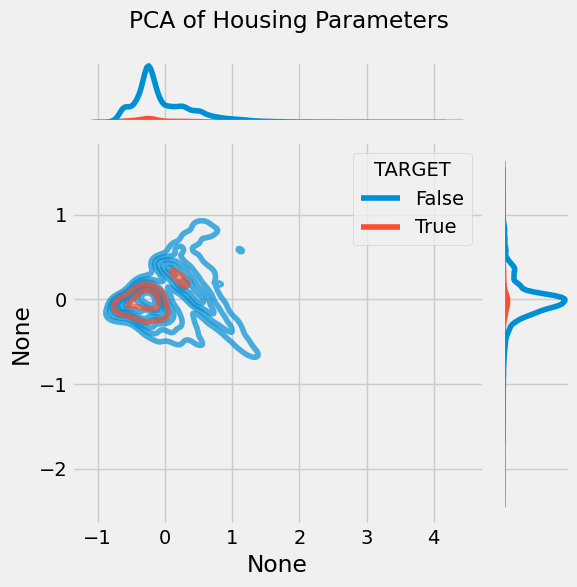

In [5]:
X = house_df.drop(columns='TARGET', inplace=False).select_dtypes(include=['number']).dropna()

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
sns.jointplot(
    x=principal_components[:, 0], 
    y=principal_components[:, 1], 
    hue=house_df.select_dtypes(include=['number', bool]).dropna(inplace=False)['TARGET'], 
    fill=False, 
    alpha=0.7, 
    kind='kde', 
    thresh=0., 
    cut=0
)

plt.suptitle('PCA of Housing Parameters')
plt.tight_layout()


two first PCA components are unable to capture any meaningful patterns of target distribution.

# EDA

## Correlation and collinearity

Text(0.5, 1.0, 'Pearson correlation for house neighbourhood parameters')

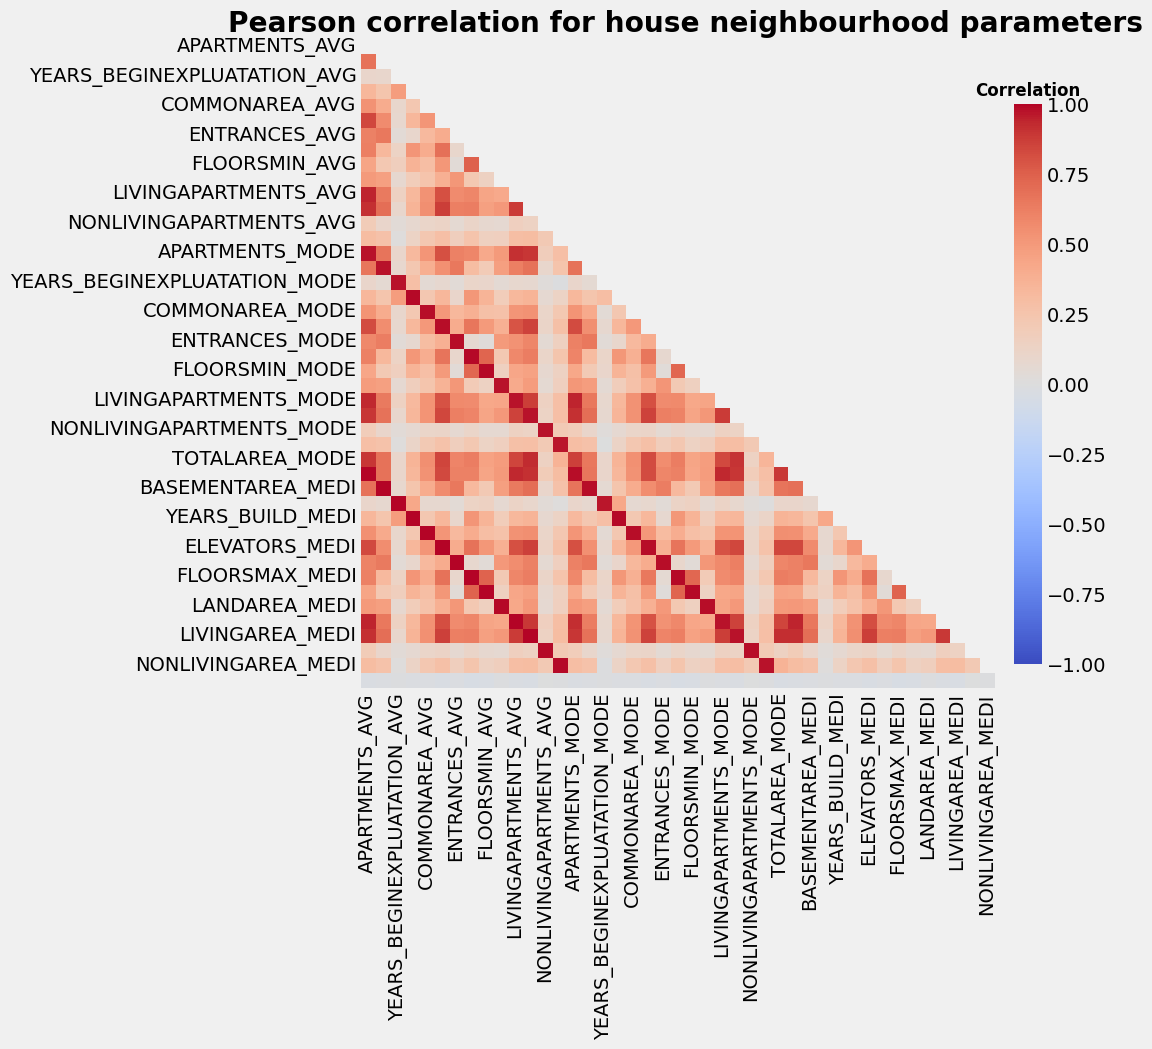

In [6]:
importlib.reload(plotting_helper)
plotting_helper.plot_corr_triangle(house_df, 'pearson', "TARGET", (12,8));
plt.title("Pearson correlation for house neighbourhood parameters")

* There is significant covariance between numerous features.
* Average (mean), Median, Mode twin statistics are very strongly correlated, which would cause linear models to fail.
    * The broad trends (ignoring hard values) seem to be mostly repeated.
* There is no association between these and the target variable.
* The broad trends, when 

Our choice of tree ensemble model is more resistant to multicollinearity than linear methods, which should decrease impact of this issue.


## Comparison of building avg, median, and mode distributions.

### Correlation

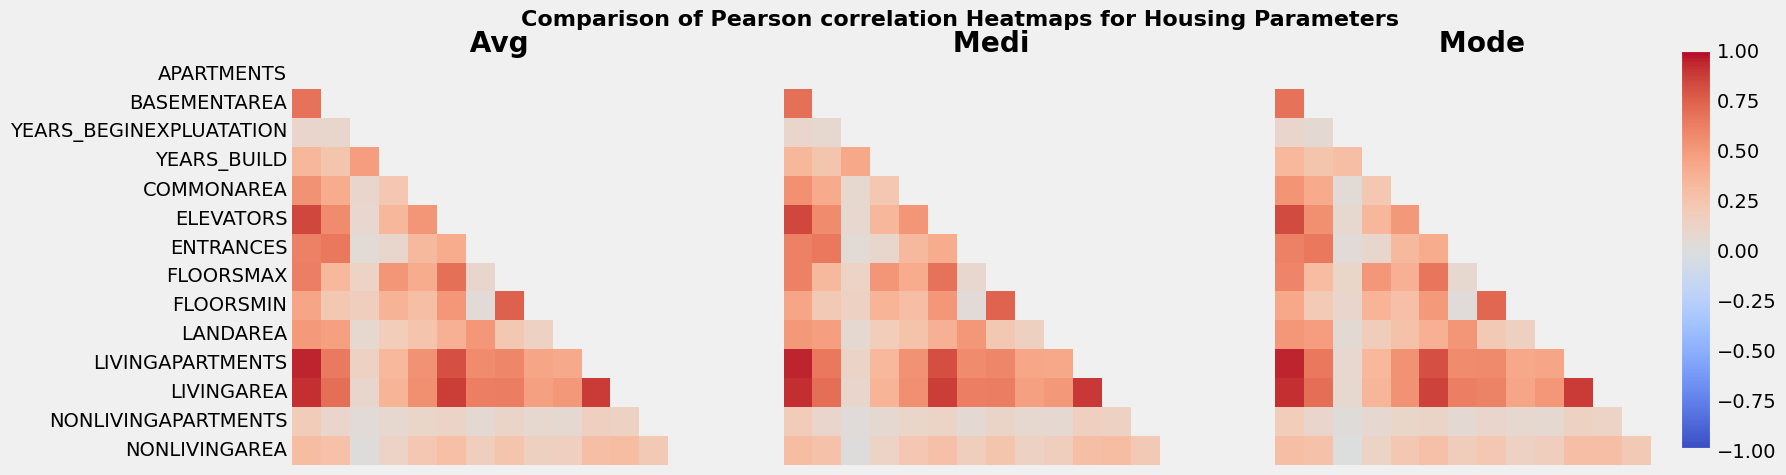

In [7]:
metric_suffixes = ["_AVG", "_MEDI", "_MODE"]
titles = ["Average (Mean)", "Median", "Mode"]

importlib.reload(plotting_helper)
importlib.reload(one_off_plots)
corr_tables = one_off_plots.plot_metric_comparison(
    house_df.drop(columns="TOTALAREA_MODE"),
    metric_suffixes,
    "Comparison of Pearson correlation Heatmaps for Housing Parameters",
    titles,
);

* Feature correlation distributions are near identical.
* These values should make the features highly interchangeable for analysis purposes.

This suggests that, quite likely, Avg, Medi, and Mode are  of identical ranking, but scaled.

In [8]:
import numpy as np
for key, corr_table in corr_tables.items():
    mask = np.triu(np.ones_like(corr_table, dtype=bool))
    masked_corr = corr_table.where(~mask, 0)
    print(f"Sum of upper triangle values for {key}: {masked_corr.values.sum()}")
    plt.show()

Sum of upper triangle values for _AVG: 31.948200113778064
Sum of upper triangle values for _MEDI: 31.75538710801566
Sum of upper triangle values for _MODE: 31.012902671205982


* The overall plot correlation values are close enough to show extremely similar association patterns.
* MODE possesses most orthogonal values.

This indicates very similar relationships, however ranking my reveal differences in trend.

#### Kendall's tau, pairwise ordering
A more precise ranking metric kendall's tau was used to evaluate whether the ranking relationship is identical. It was chosen over spearman correlation due to robustness to outliers and simpler interpretation. Both techniques are preferable for non-parametric data.

kendall's tau measures the correspondence between two rankings. It ranges in values from -1 (strong disagreement) to +1 (strong agreement).

In [9]:
stats_helper.compare_ordering_metrics(house_df, metric_suffixes, test=stats.kendalltau)

,_AVG vs _MEDI,_AVG vs _MODE,_MEDI vs _MODE,Bonferroni sum p_value
Feature,,,,
APARTMENTS,0.982906,0.925403,0.938032,0.0
BASEMENTAREA,0.981985,0.919794,0.929244,0.0
YEARS_BEGINEXPLUATATION,0.991102,0.963821,0.968883,0.0
YEARS_BUILD,0.993442,0.969653,0.973709,0.0
COMMONAREA,0.987001,0.935826,0.944662,0.0
ELEVATORS,0.983990,0.947926,0.963020,0.0
ENTRANCES,0.983204,0.927754,0.944184,0.0
FLOORSMAX,0.987701,0.963604,0.975208,0.0
FLOORSMIN,0.989972,0.966797,0.976396,0.0


* Extremely strong association (>0.9) was observed between all variables.
    * AVG vs MEDIUM ordering is near identical - mean column corr  0.98
    * AVG appears to be slightly less representative of MODE (mean column corr ~0.94), for which MEDIAN is more representative (mean column corr ~0.95).

Consequently, given the nature of ensemble tree classifiers (ignored shape of variables), we can choose a single metric for the model. In this context, **Median best represents two other metrics and is easy to interpret**. 

In [ ]:
discard_columns = [
    col
    for col in house_df.columns
    if (
        col.endswith(("_AVG", "_MODE"))
        and col.replace("_MODE", "_AVG") in house_df.columns 
    )
]
discard_columns

['APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_AVG',
 'YEARS_BUILD_AVG',
 'COMMONAREA_AVG',
 'ELEVATORS_AVG',
 'ENTRANCES_AVG',
 'FLOORSMAX_AVG',
 'FLOORSMIN_AVG',
 'LANDAREA_AVG',
 'LIVINGAPARTMENTS_AVG',
 'LIVINGAREA_AVG',
 'NONLIVINGAPARTMENTS_AVG',
 'NONLIVINGAREA_AVG',
 'APARTMENTS_MODE',
 'BASEMENTAREA_MODE',
 'YEARS_BEGINEXPLUATATION_MODE',
 'YEARS_BUILD_MODE',
 'COMMONAREA_MODE',
 'ELEVATORS_MODE',
 'ENTRANCES_MODE',
 'FLOORSMAX_MODE',
 'FLOORSMIN_MODE',
 'LANDAREA_MODE',
 'LIVINGAPARTMENTS_MODE',
 'LIVINGAREA_MODE',
 'NONLIVINGAPARTMENTS_MODE',
 'NONLIVINGAREA_MODE']

### VIF comparison of feature reduction.

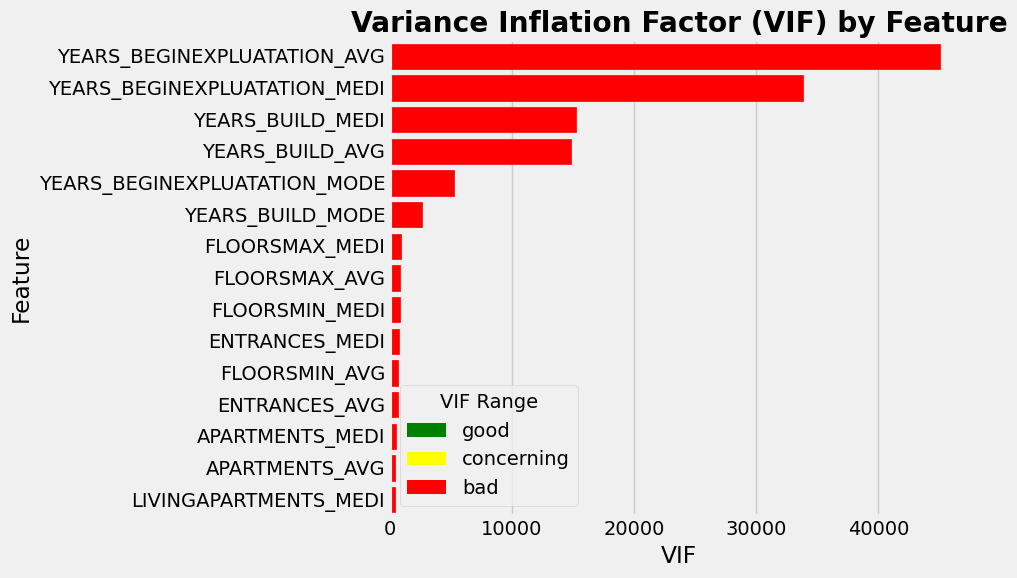

In [10]:
from helpers.utils import vif_helper
importlib.reload(vif_helper)
vif_helper.plot_vif(house_df, top_n=15);

**VIF is unacceptable. Feature selection is required.**

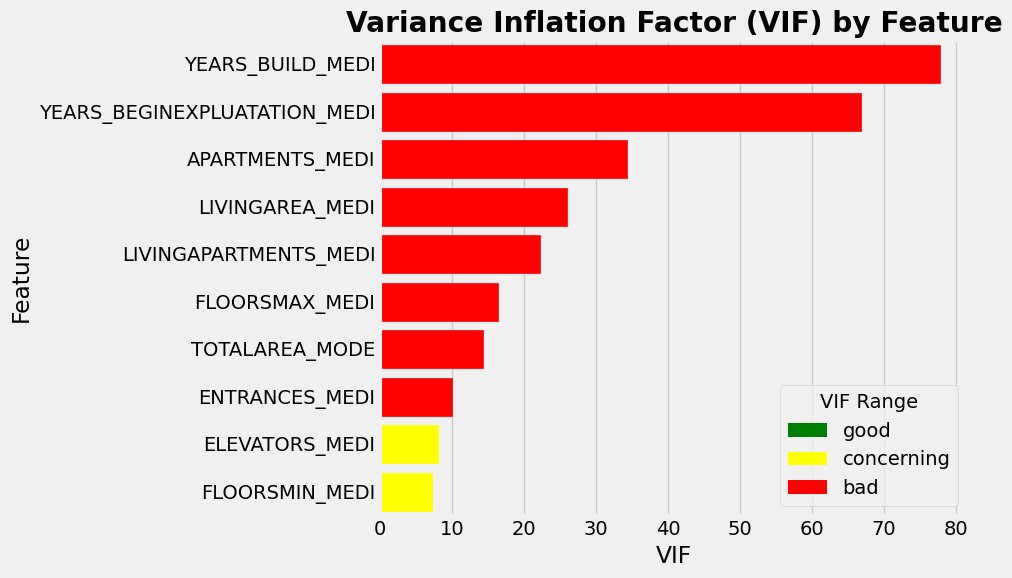

In [ ]:

print(discard_columns)

vif_helper.plot_vif(house_df.drop(columns=discard_columns));

* Although VIF is still too high, it was significantly reduced.

## Selected model training

In [59]:
from helpers import submissions
importlib.reload(submissions)
importlib.reload(preprocessing)
app = preprocessing.load_pkl_to_preprocessor('application_train')
app.convert_all('category')

X_train, y_train, _ = app.get_X_y_id()
X_train.drop(columns=discard_columns, inplace=True)


test_processor = preprocessing.load_pkl_to_preprocessor('application_test')
test_processor.convert_all('category')
X_test, y_test, id_test = test_processor.get_X_y_id()
X_test.drop(columns=discard_columns, inplace=True)

Loading tables: ['application_train.csv']
loaded application_train with shape (307511, 122)
No missing columns.
Unexpected columns: ['SK_ID_CURR']
X shape: (307511, 120), y shape: (307511,), id shape: (307511,)
Loading tables: ['application_test.csv']
loaded application_test with shape (48744, 121)
No missing columns.
Unexpected columns: ['SK_ID_CURR']
X shape: (48744, 120), y shape: None, id shape: (48744,)


C:\Users\326po\AppData\Local\Temp\ipykernel_11272\2764409306.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test.drop(columns=discard_columns, inplace=True)


In [60]:
submissions.cv_lgbm(X_train, y_train)

,average_precision,roc_auc,f1_macro
0,0.2404,0.7567,0.5428



Crossvalidation results appear to be almost identical to original ones:
| Average Precision | ROC AUC | F1 Macro |
|-------------------|---------|----------|
| 0.2408            | 0.7568  | 0.5428   |



#### submission test:


In [62]:
importlib.reload(submissions)
submissions.prepare_submission(
    lightgbm.LGBMClassifier(is_unbalance=True, random_state=3, verbose=-1).fit(X_train, y_train), 
    X_test, 
    id_test,
    'house_features_reduced'
)

Submission created: submissions\sub_2025-07-14_13-11_house_features_reduced.csv


'submissions\\sub_2025-07-14_13-11_house_features_reduced.csv'

Test ROC_AUC has decreased from:
* 0.74262 to 0.74057.
Consequently, the feature selection procedure was detrimental. 

# Average correlation

### median features correlation

Even pearson correlations 

We firs